IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


sns.set_theme(style="whitegrid")

IMPORTING THE DATASET

In [2]:

url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
df = pd.read_csv(url, index_col=0)

# Display the first 5 rows
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


PLOTTING THE DATA

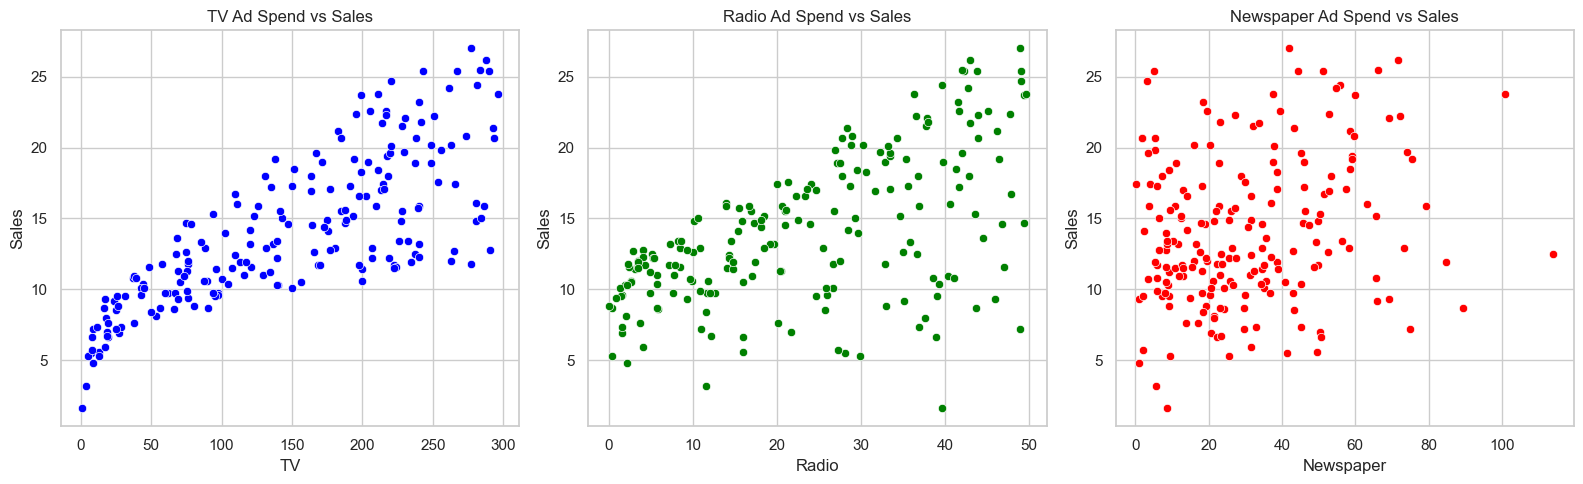

In [3]:
# Create a figure with 3 side-by-side charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: TV vs Sales
sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0], color='blue')
axes[0].set_title('TV Ad Spend vs Sales')

# Chart 2: Radio vs Sales
sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1], color='green')
axes[1].set_title('Radio Ad Spend vs Sales')

# Chart 3: Newspaper vs Sales
sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[2], color='red')
axes[2].set_title('Newspaper Ad Spend vs Sales')

plt.tight_layout()
plt.show()

TRAIN_TEST_SPLIT

In [4]:
x= df[['TV','Radio','Newspaper']]
y= df['Sales']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


TRAINING THE REGRESSION MODEL ON THE TRAIN DATA

In [5]:
model = LinearRegression()
model.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


CALCULATING COEFFICIENTS

In [6]:
print(f"Base Sales (Intercept): {model.intercept_:.2f}")
print("--- Return on Investment (Coefficients) ---")
for feature, coef in zip(x.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")


Base Sales (Intercept): 2.98
--- Return on Investment (Coefficients) ---
TV: 0.0447
Radio: 0.1892
Newspaper: 0.0028


CALCULATION OUTPUT FEATURES BASED OF DATA AND CALCULATING : - (MSE,R_SQUARED)

In [7]:
# 1. Ask the model to predict sales for the 20% test data
predictions = model.predict(x_test)
#PREDICTING VALUES AND CALCULATING ( MSE,R_SQAURED)
# 2. Calculate how accurate it was
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared Score: {r2:.6f}")



Mean Squared Error: 3.1741
R-Squared Score: 0.899438


PLOTTING THE CALCULATED SALES VS ACTUAL SALES :

THE STRAIGHT LINE REPRESENTS THE IDEAL CASE
THE CLOSER THE POINTS ARE TO THIS LINE THE MORE ACCURATE THE MODEL IS

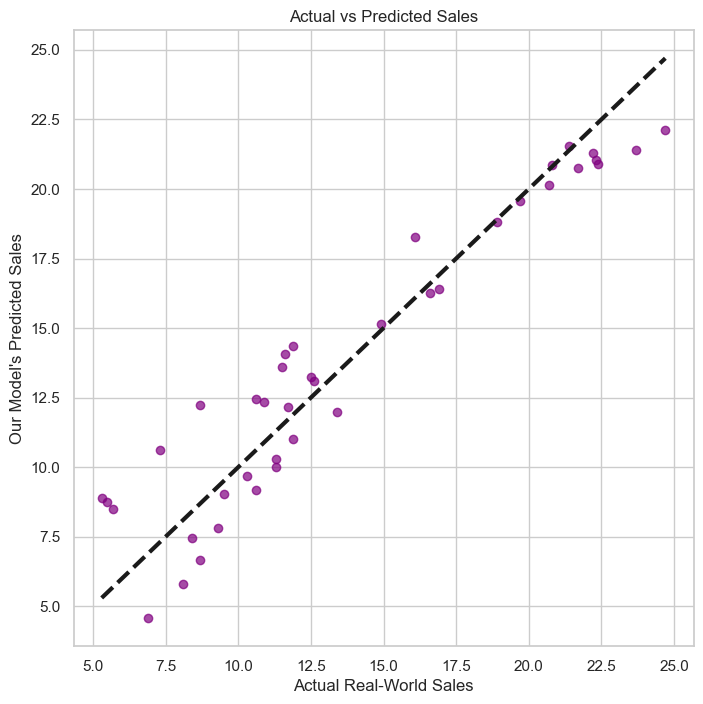

In [8]:
# 3. Visualize our predictions vs the actual results
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, color='purple', alpha=0.7)

# Draw a perfect prediction line (where Prediction = Actual)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)

plt.xlabel('Actual Real-World Sales')
plt.ylabel('Our Model\'s Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()






EFFICIENCY OF EACH MARKETING STRATEGY(PER $1000 SPENT ON IT)

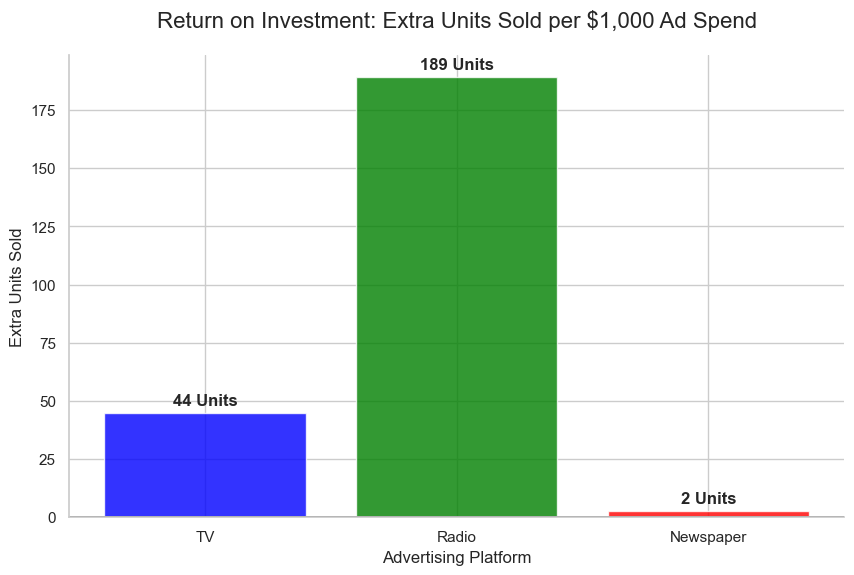

In [9]:
roi_data = {
    'TV': model.coef_[0] * 1000,
    'Radio': model.coef_[1] * 1000,
    'Newspaper': model.coef_[2] * 1000
}

# 2. Create the Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(roi_data.keys(), roi_data.values(), color=['blue', 'green', 'red'], alpha=0.8)


for bar in bars:
    height = bar.get_height()
    # Format the text to show units (e.g., "189 Units")
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)} Units',
             ha='center', va='bottom', fontweight='bold', fontsize=12)


plt.axhline(0, color='black', linewidth=1.2) # Draw a bold line at 0
plt.title('Return on Investment: Extra Units Sold per $1,000 Ad Spend', fontsize=16, pad=20)
plt.ylabel('Extra Units Sold', fontsize=12)
plt.xlabel('Advertising Platform', fontsize=12)

sns.despine()

plt.show()